<h1 style="text-align:center; color:#FF5733;">Clustering With K Means</h1>

<h3 style="color :#9B59B6 ">A. Libraries imported</h3>

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
import seaborn as sns 
%matplotlib inline

<h3 style="color :#9B59B6 ">B. Extract Data </h3>
<p> First step in any data analysis or machine learning project, as it allows us to access and manipulate the data in a structured format.</p>

In [2]:
df = pd.read_csv("Mall_Customers.csv")

<h3 style="color :#9B59B6 ">B. Exploring dataset</h3>

In [3]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


<p>Show numbers of rows and column</p> 

In [6]:
print('Number Of Rows : ',df.shape[0])

Number Of Rows :  200


In [7]:
print('Number Of Columns : ',df.shape[1])

Number Of Columns :  5


<p>Get all variable name</p>

In [8]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

<p>Get All Data type of varibale</p>

In [9]:
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

<p>General information about dataset</p>

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<p>Generale Information Type Statique</p>

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<p>Detect null values for each variable</p>

In [12]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<p>Detecte sum of null value in our dataset</p>

In [13]:
df.isnull().sum().sum()

0

<p>Graphical representation to detect Nan values</p>

<AxesSubplot:>

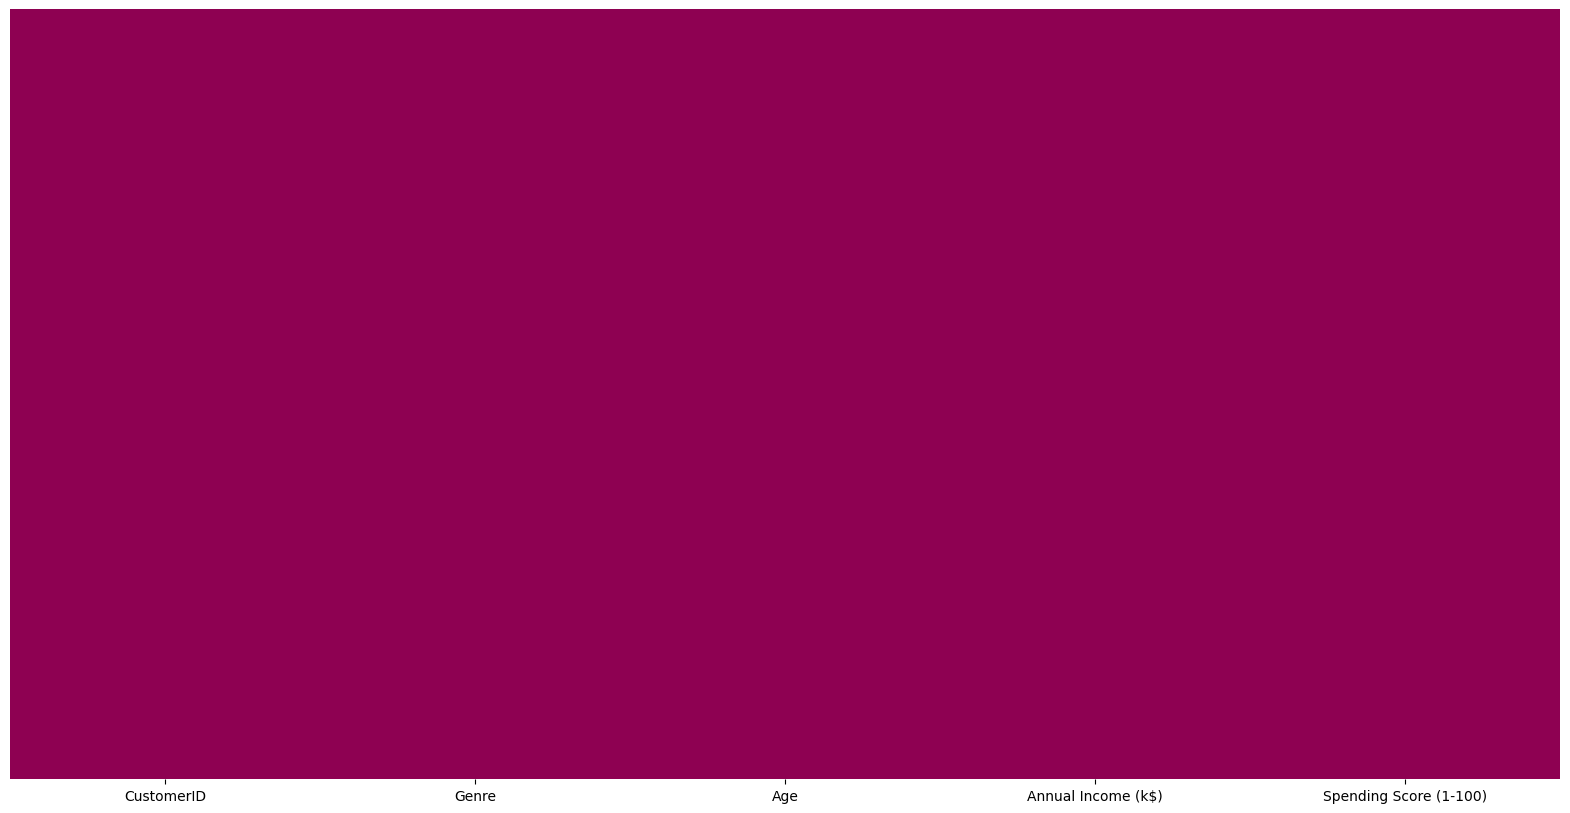

In [14]:
from matplotlib import pyplot as plt
plt.figure(figsize=(20,10)) #Dimension du GRAPHIQUE
sns.heatmap(df.isna(),yticklabels=False,cmap='PiYG',cbar=False)

<h3 style="color :#9B59B6 ">C. Transform Data </h3>

<p>Delete Columns</p>

In [16]:
# Drop the CustomerID column
df = df.drop('CustomerID', axis=1)

# Drop the Spending Score (1-100) column
df = df.drop('Spending Score (1-100)', axis=1)

# Drop the Genre column
df = df.drop('Genre', axis=1)

In [17]:
df

,Age,Annual Income (k$)
0,19,15
1,21,15
2,20,16
3,23,16
4,31,17
...,...,...
195,35,120
196,45,126
197,32,126
198,32,137


<h3 style="color :#9B59B6 ">D .Clustering With K Means</h3>

<p>create a scatter plot of the "Age" and "Annual Income (k$)" columns in the DataFrame df.</p>

Text(0, 0.5, 'Annual Income (k$)')

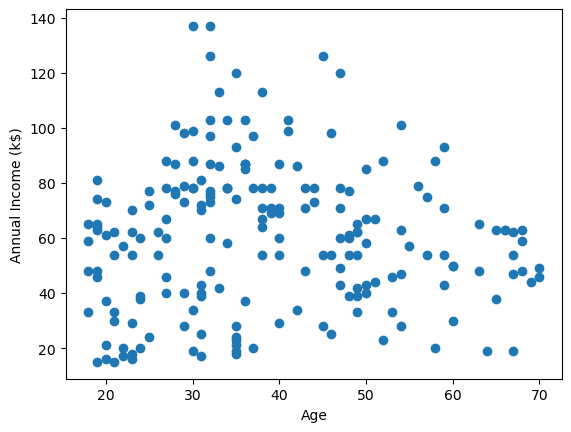

In [19]:
plt.scatter(df['Age'],df['Annual Income (k$)'])
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

<p>Clustering on the "Age" and "Annual Income (k$)" columns of the DataFrame df </p>

In [22]:
km = KMeans(n_clusters=3, n_init=10)
y_predicted = km.fit_predict(df[['Age','Annual Income (k$)']])
y_predicted

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

<p>Adds a new column called "cluster" to the DataFrame df</p>

In [26]:
df['cluster']=y_predicted
df.head(10)

,Age,Annual Income (k$),cluster
0,19,15,2
1,21,15,2
2,20,16,2
3,23,16,2
4,31,17,2
5,22,17,2
6,35,18,2
7,23,18,2
8,64,19,0
9,30,19,2


In [24]:
df.tail()

,Age,Annual Income (k$),cluster
195,35,120,1
196,45,126,1
197,32,126,1
198,32,137,1
199,30,137,1


<p>Coordinates of the centroids of the clusters identified by the k-means algorithm </p>

In [27]:
km.cluster_centers_

array([[55.03448276, 50.34482759],
       [34.34782609, 82.82608696],
       [28.36      , 31.44      ]])

<p>Visualize the clusters that were identified by the k-means algorithm.</p>

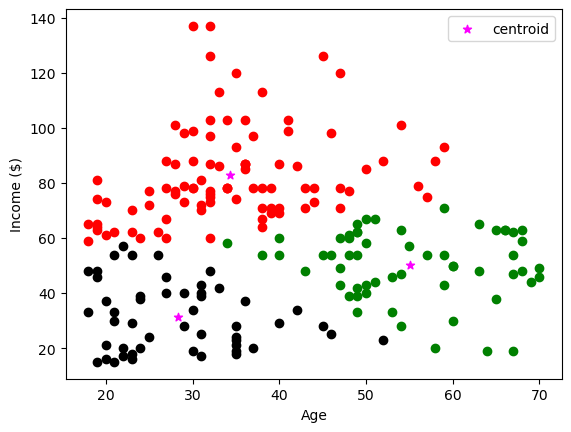

In [33]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Annual Income (k$)'],color='green')
plt.scatter(df2.Age,df2['Annual Income (k$)'],color='red')
plt.scatter(df3.Age,df3['Annual Income (k$)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='#FB00FF',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()

<h4 style="color :#9B59B6 ">D.1 Elbow Plot</h4>

<p>Elbow plot is a graph that shows the relationship between the number of clusters and the sum of squared errors (SSE) in the k-means algorithm. It is used to <b><u>Identify the optimal number of clusters</u></b> for a given datase</p>

In [39]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(df[['Age','Annual Income (k$)']])
    sse.append(km.inertia_)

<p>creates a plot of the number of clusters (k) on the x-axis and the corresponding sum of squared errors (SSE) on the y-axis</p>

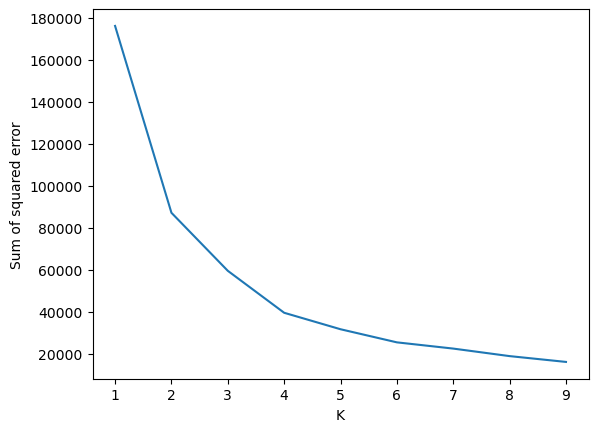

In [40]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

<p>Clustrring with optimle K=4 </p>

In [42]:
km = KMeans(n_clusters=4, n_init=10)
y_predicted = km.fit_predict(df[['Age','Annual Income (k$)']])
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3])

<p>Adds a new column called "cluster" to the DataFrame df</p>

In [50]:
df['cluster']=y_predicted
df.head(10)

,Age,Annual Income (k$),cluster
0,19,15,1
1,21,15,1
2,20,16,1
3,23,16,1
4,31,17,1
5,22,17,1
6,35,18,1
7,23,18,1
8,64,19,0
9,30,19,1


In [48]:
df.tail()

,Age,Annual Income (k$),cluster
195,35,120,3
196,45,126,3
197,32,126,3
198,32,137,3
199,30,137,3


<p>Coordinates of the centroids  4 of the clusters 4 identified by the k-means algorithm </p>

In [52]:
km.cluster_centers_

array([[ 55.81481481,  51.77777778],
       [ 30.34693878,  29.26530612],
       [ 31.95890411,  72.95890411],
       [ 39.        , 106.5       ]])

<p>Visualize the clusters that were identified by the k-means algorithm.</p>

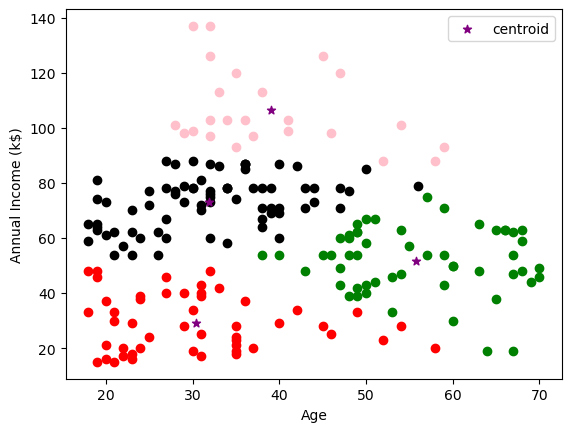

In [53]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
df4 = df[df.cluster==3]


plt.scatter(df1.Age,df1['Annual Income (k$)'],color='green')
plt.scatter(df2.Age,df2['Annual Income (k$)'],color='red')
plt.scatter(df3.Age,df3['Annual Income (k$)'],color='black')
plt.scatter(df4.Age,df4['Annual Income (k$)'],color='pink')


plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend()

<h1 style="text-align:center; color:#FF5733;">Enjoy..</h1>